In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
from pathlib import Path

In [2]:
from thermofeel import thermofeel

def calculate_relative_humidity_percent(t2_k, td_k):
    t2_c = kelvin_to_celsius(t2_k)
    td_c = kelvin_to_celsius(td_k)
    # saturated vapour pressure
    es = 6.11 * 10.0 ** (7.5 * t2_c / (237.3 + t2_c))
    # vapour pressure
    e = 6.11 * 10.0 ** (7.5 * td_c / (237.3 + td_c))
    rh = (e / es) * 100
    return rh

def calculate_saturation_vapour_pressure(t2_k):
    g = [
        -2.8365744e3,
        -6.028076559e3,
        1.954263612e1,
        -2.737830188e-2,
        1.6261698e-5,
        7.0229056e-10,
        -1.8680009e-13,
        2.7150305,
    ]
    ess = g[7] * np.log(t2_k)
    for i in range(7):
        ess = ess + g[i] * np.power(t2_k, (i - 2))
    ess = np.exp(ess) * 0.01  # hPa
    return ess

def kelvin_to_celsius(temp_k):
    """Convert Kelvin to Celsius preserving xarray metadata"""
    return temp_k - 273.15

def celsius_to_kelvin(temp_c):

    """Convert Celsius to Kelvin preserving xarray metadata"""
    return temp_c + 273.15

def calculate_utci_polynomial(t2m, mrt, va, wvp):
    """
    Helper function to calculate the UTCI polynomial approximation
        :param t2_k: (float array) is 2m temperature [K]
        :param mrt: (float array) is mean radiant temperature [K]
        :param va: (float array) is wind speed at 10 meters [m/s]
        :param wvp: (float array) is water vapour pressure [kPa]
    returns UTCI [K]
    Reference: Brode et al. (2012)
    https://doi.org/10.1007/s00484-011-0454-1
    """
    e_mrt = np.subtract(mrt, t2m)

    t2m2 = t2m * t2m
    t2m3 = t2m2 * t2m
    t2m4 = t2m3 * t2m
    t2m5 = t2m4 * t2m
    t2m6 = t2m5 * t2m

    va2 = va * va
    va3 = va2 * va
    va4 = va3 * va
    va5 = va4 * va
    va6 = va5 * va

    e_mrt2 = e_mrt * e_mrt
    e_mrt3 = e_mrt2 * e_mrt
    e_mrt4 = e_mrt3 * e_mrt
    e_mrt5 = e_mrt4 * e_mrt
    e_mrt6 = e_mrt5 * e_mrt

    wvp2 = wvp * wvp
    wvp3 = wvp2 * wvp
    wvp4 = wvp3 * wvp
    wvp5 = wvp4 * wvp
    wvp6 = wvp5 * wvp

    varh2 = va * wvp2
    va2_rh = va2 * wvp
    va2_e_mrt = va2 * e_mrt
    e_mrt_rh = e_mrt * wvp
    e_mrt_rh2 = e_mrt * wvp2
    e_mrt2_rh = e_mrt2 * wvp
    e_mrt2_rh2 = e_mrt2 * wvp2
    e_mrt_rh3 = e_mrt * wvp3
    va_e_mrt = va * e_mrt
    va_e_mrt2 = va * e_mrt2
    va_rh = va * wvp
    t2m_va = t2m * va
    e_mrt3_rh = e_mrt3 * wvp
    e_mrt4_rh = e_mrt4 * wvp

    utci = (
        t2m
        + 6.07562052e-01
        + -2.27712343e-02 * t2m
        + 8.06470249e-04 * t2m2
        + -1.54271372e-04 * t2m3
        + -3.24651735e-06 * t2m4
        + 7.32602852e-08 * t2m5
        + 1.35959073e-09 * t2m6
        + -2.25836520e00 * va
        + 8.80326035e-02 * t2m * va
        + 2.16844454e-03 * t2m2 * va
        + -1.53347087e-05 * t2m3 * va
        + -5.72983704e-07 * t2m4 * va
        + -2.55090145e-09 * t2m5 * va
        + -7.51269505e-01 * va2
        + -4.08350271e-03 * t2m * va2
        + -5.21670675e-05 * t2m2 * va2
        + 1.94544667e-06 * t2m3 * va2
        + 1.14099531e-08 * t2m4 * va2
        + 1.58137256e-01 * va3
        + -6.57263143e-05 * t2m * va3
        + 2.22697524e-07 * t2m2 * va3
        + -4.16117031e-08 * t2m3 * va3
        + -1.27762753e-02 * va4
        + 9.66891875e-06 * t2m * va4
        + 2.52785852e-09 * t2m2 * va4
        + 4.56306672e-04 * va5
        + -1.74202546e-07 * t2m * va5
        + -5.91491269e-06 * va6
        + 3.98374029e-01 * e_mrt
        + 1.83945314e-04 * t2m * e_mrt
        + -1.73754510e-04 * t2m2 * e_mrt
        + -7.60781159e-07 * t2m3 * e_mrt
        + 3.77830287e-08 * t2m4 * e_mrt
        + 5.43079673e-10 * t2m5 * e_mrt
        + -2.00518269e-02 * va_e_mrt
        + 8.92859837e-04 * t2m * va_e_mrt
        + 3.45433048e-06 * t2m2 * va_e_mrt
        + -3.77925774e-07 * t2m3 * va_e_mrt
        + -1.69699377e-09 * t2m4 * va_e_mrt
        + 1.69992415e-04 * va2_e_mrt
        + -4.99204314e-05 * t2m * va2_e_mrt
        + 2.47417178e-07 * t2m2 * va2_e_mrt
        + 1.07596466e-08 * t2m3 * va2_e_mrt
        + 8.49242932e-05 * va3 * e_mrt
        + 1.35191328e-06 * t2m * va3 * e_mrt
        + -6.21531254e-09 * t2m2 * va3 * e_mrt
        + -4.99410301e-06 * va4 * e_mrt
        + -1.89489258e-08 * t2m * va4 * e_mrt
        + 8.15300114e-08 * va5 * e_mrt
        + 7.55043090e-04 * e_mrt2
        + -5.65095215e-05 * t2m * e_mrt2
        + -4.52166564e-07 * t2m2 * e_mrt2
        + 2.46688878e-08 * t2m3 * e_mrt2
        + 2.42674348e-10 * t2m4 * e_mrt2
        + 1.54547250e-04 * va_e_mrt2
        + 5.24110970e-06 * t2m * va_e_mrt2
        + -8.75874982e-08 * t2m2 * va_e_mrt2
        + -1.50743064e-09 * t2m3 * va_e_mrt2
        + -1.56236307e-05 * va2 * e_mrt2
        + -1.33895614e-07 * t2m * va2 * e_mrt2
        + 2.49709824e-09 * t2m2 * va2 * e_mrt2
        + 6.51711721e-07 * va3 * e_mrt2
        + 1.94960053e-09 * t2m * va3 * e_mrt2
        + -1.00361113e-08 * va4 * e_mrt2
        + -1.21206673e-05 * e_mrt3
        + -2.18203660e-07 * t2m * e_mrt3
        + 7.51269482e-09 * t2m2 * e_mrt3
        + 9.79063848e-11 * t2m3 * e_mrt3
        + 1.25006734e-06 * va * e_mrt3
        + -1.81584736e-09 * t2m_va * e_mrt3
        + -3.52197671e-10 * t2m2 * va * e_mrt3
        + -3.36514630e-08 * va2 * e_mrt3
        + 1.35908359e-10 * t2m * va2 * e_mrt3
        + 4.17032620e-10 * va3 * e_mrt3
        + -1.30369025e-09 * e_mrt4
        + 4.13908461e-10 * t2m * e_mrt4
        + 9.22652254e-12 * t2m2 * e_mrt4
        + -5.08220384e-09 * va * e_mrt4
        + -2.24730961e-11 * t2m_va * e_mrt4
        + 1.17139133e-10 * va2 * e_mrt4
        + 6.62154879e-10 * e_mrt5
        + 4.03863260e-13 * t2m * e_mrt5
        + 1.95087203e-12 * va * e_mrt5
        + -4.73602469e-12 * e_mrt6
        + 5.12733497e00 * wvp
        + -3.12788561e-01 * t2m * wvp
        + -1.96701861e-02 * t2m2 * wvp
        + 9.99690870e-04 * t2m3 * wvp
        + 9.51738512e-06 * t2m4 * wvp
        + -4.66426341e-07 * t2m5 * wvp
        + 5.48050612e-01 * va_rh
        + -3.30552823e-03 * t2m * va_rh
        + -1.64119440e-03 * t2m2 * va_rh
        + -5.16670694e-06 * t2m3 * va_rh
        + 9.52692432e-07 * t2m4 * va_rh
        + -4.29223622e-02 * va2_rh
        + 5.00845667e-03 * t2m * va2_rh
        + 1.00601257e-06 * t2m2 * va2_rh
        + -1.81748644e-06 * t2m3 * va2_rh
        + -1.25813502e-03 * va3 * wvp
        + -1.79330391e-04 * t2m * va3 * wvp
        + 2.34994441e-06 * t2m2 * va3 * wvp
        + 1.29735808e-04 * va4 * wvp
        + 1.29064870e-06 * t2m * va4 * wvp
        + -2.28558686e-06 * va5 * wvp
        + -3.69476348e-02 * e_mrt_rh
        + 1.62325322e-03 * t2m * e_mrt_rh
        + -3.14279680e-05 * t2m2 * e_mrt_rh
        + 2.59835559e-06 * t2m3 * e_mrt_rh
        + -4.77136523e-08 * t2m4 * e_mrt_rh
        + 8.64203390e-03 * va * e_mrt_rh
        + -6.87405181e-04 * t2m_va * e_mrt_rh
        + -9.13863872e-06 * t2m2 * va * e_mrt_rh
        + 5.15916806e-07 * t2m3 * va * e_mrt_rh
        + -3.59217476e-05 * va2 * e_mrt_rh
        + 3.28696511e-05 * t2m * va2 * e_mrt_rh
        + -7.10542454e-07 * t2m2 * va2 * e_mrt_rh
        + -1.24382300e-05 * va3 * e_mrt_rh
        + -7.38584400e-09 * t2m * va3 * e_mrt_rh
        + 2.20609296e-07 * va4 * e_mrt_rh
        + -7.32469180e-04 * e_mrt2_rh
        + -1.87381964e-05 * t2m * e_mrt2_rh
        + 4.80925239e-06 * t2m2 * e_mrt2_rh
        + -8.75492040e-08 * t2m3 * e_mrt2_rh
        + 2.77862930e-05 * va * e_mrt2_rh
        + -5.06004592e-06 * t2m_va * e_mrt2_rh
        + 1.14325367e-07 * t2m2 * va * e_mrt2_rh
        + 2.53016723e-06 * va2 * e_mrt2_rh
        + -1.72857035e-08 * t2m * va2 * e_mrt2_rh
        + -3.95079398e-08 * va3 * e_mrt2_rh
        + -3.59413173e-07 * e_mrt3_rh
        + 7.04388046e-07 * t2m * e_mrt3_rh
        + -1.89309167e-08 * t2m2 * e_mrt3_rh
        + -4.79768731e-07 * va * e_mrt3_rh
        + 7.96079978e-09 * t2m_va * e_mrt3_rh
        + 1.62897058e-09 * va2 * e_mrt3_rh
        + 3.94367674e-08 * e_mrt4_rh
        + -1.18566247e-09 * t2m * e_mrt4_rh
        + 3.34678041e-10 * va * e_mrt4_rh
        + -1.15606447e-10 * e_mrt5 * wvp
        + -2.80626406e00 * wvp2
        + 5.48712484e-01 * t2m * wvp2
        + -3.99428410e-03 * t2m2 * wvp2
        + -9.54009191e-04 * t2m3 * wvp2
        + 1.93090978e-05 * t2m4 * wvp2
        + -3.08806365e-01 * varh2
        + 1.16952364e-02 * t2m * varh2
        + 4.95271903e-04 * t2m2 * varh2
        + -1.90710882e-05 * t2m3 * varh2
        + 2.10787756e-03 * va2 * wvp2
        + -6.98445738e-04 * t2m * va2 * wvp2
        + 2.30109073e-05 * t2m2 * va2 * wvp2
        + 4.17856590e-04 * va3 * wvp2
        + -1.27043871e-05 * t2m * va3 * wvp2
        + -3.04620472e-06 * va4 * wvp2
        + 5.14507424e-02 * e_mrt_rh2
        + -4.32510997e-03 * t2m * e_mrt_rh2
        + 8.99281156e-05 * t2m2 * e_mrt_rh2
        + -7.14663943e-07 * t2m3 * e_mrt_rh2
        + -2.66016305e-04 * va * e_mrt_rh2
        + 2.63789586e-04 * t2m_va * e_mrt_rh2
        + -7.01199003e-06 * t2m2 * va * e_mrt_rh2
        + -1.06823306e-04 * va2 * e_mrt_rh2
        + 3.61341136e-06 * t2m * va2 * e_mrt_rh2
        + 2.29748967e-07 * va3 * e_mrt_rh2
        + 3.04788893e-04 * e_mrt2_rh2
        + -6.42070836e-05 * t2m * e_mrt2_rh2
        + 1.16257971e-06 * t2m2 * e_mrt2_rh2
        + 7.68023384e-06 * va * e_mrt2_rh2
        + -5.47446896e-07 * t2m_va * e_mrt2_rh2
        + -3.59937910e-08 * va2 * e_mrt2_rh2
        + -4.36497725e-06 * e_mrt3 * wvp2
        + 1.68737969e-07 * t2m * e_mrt3 * wvp2
        + 2.67489271e-08 * va * e_mrt3 * wvp2
        + 3.23926897e-09 * e_mrt4 * wvp2
        + -3.53874123e-02 * wvp3
        + -2.21201190e-01 * t2m * wvp3
        + 1.55126038e-02 * t2m2 * wvp3
        + -2.63917279e-04 * t2m3 * wvp3
        + 4.53433455e-02 * va * wvp3
        + -4.32943862e-03 * t2m_va * wvp3
        + 1.45389826e-04 * t2m2 * va * wvp3
        + 2.17508610e-04 * va2 * wvp3
        + -6.66724702e-05 * t2m * va2 * wvp3
        + 3.33217140e-05 * va3 * wvp3
        + -2.26921615e-03 * e_mrt_rh3
        + 3.80261982e-04 * t2m * e_mrt_rh3
        + -5.45314314e-09 * t2m2 * e_mrt_rh3
        + -7.96355448e-04 * va * e_mrt_rh3
        + 2.53458034e-05 * t2m_va * e_mrt_rh3
        + -6.31223658e-06 * va2 * e_mrt_rh3
        + 3.02122035e-04 * e_mrt2 * wvp3
        + -4.77403547e-06 * t2m * e_mrt2 * wvp3
        + 1.73825715e-06 * va * e_mrt2 * wvp3
        + -4.09087898e-07 * e_mrt3 * wvp3
        + 6.14155345e-01 * wvp4
        + -6.16755931e-02 * t2m * wvp4
        + 1.33374846e-03 * t2m2 * wvp4
        + 3.55375387e-03 * va * wvp4
        + -5.13027851e-04 * t2m_va * wvp4
        + 1.02449757e-04 * va2 * wvp4
        + -1.48526421e-03 * e_mrt * wvp4
        + -4.11469183e-05 * t2m * e_mrt * wvp4
        + -6.80434415e-06 * va * e_mrt * wvp4
        + -9.77675906e-06 * e_mrt2 * wvp4
        + 8.82773108e-02 * wvp5
        + -3.01859306e-03 * t2m * wvp5
        + 1.04452989e-03 * va * wvp5
        + 2.47090539e-04 * e_mrt * wvp5
        + 1.48348065e-03 * wvp6
    )

    return utci

def calculate_UTCI(tas, mrt, ws, wvp):
    tas_c = kelvin_to_celsius(tas)  # polynomial approx. is in Celsius
    mrt_c = kelvin_to_celsius(mrt)  # polynomial approx. is in Celsius

    utci = calculate_utci_polynomial(tas_c, mrt_c, ws, wvp)
    utci_k = celsius_to_kelvin(utci)
    return utci_k

In [3]:
def compute_indicative_UTCIS(means, varname, var_range):
    # Use baseline values by default
    inputs = {
        'tas': means.tas.item(),
        'MRT': means.MRT.item(),
        'ws': means.ws.item(),
        'wvp': means.wvp.item(),
    }
    UTCI_range = []
    for value in var_range:
        inputs[varname] = value
        UTCI = calculate_UTCI(inputs['tas'] + 273.15, 
                              inputs['MRT'] + 273.15, 
                              inputs['ws'], 
                              inputs['wvp'])
        UTCI_range.append(UTCI - 273.15)
    return UTCI_range 

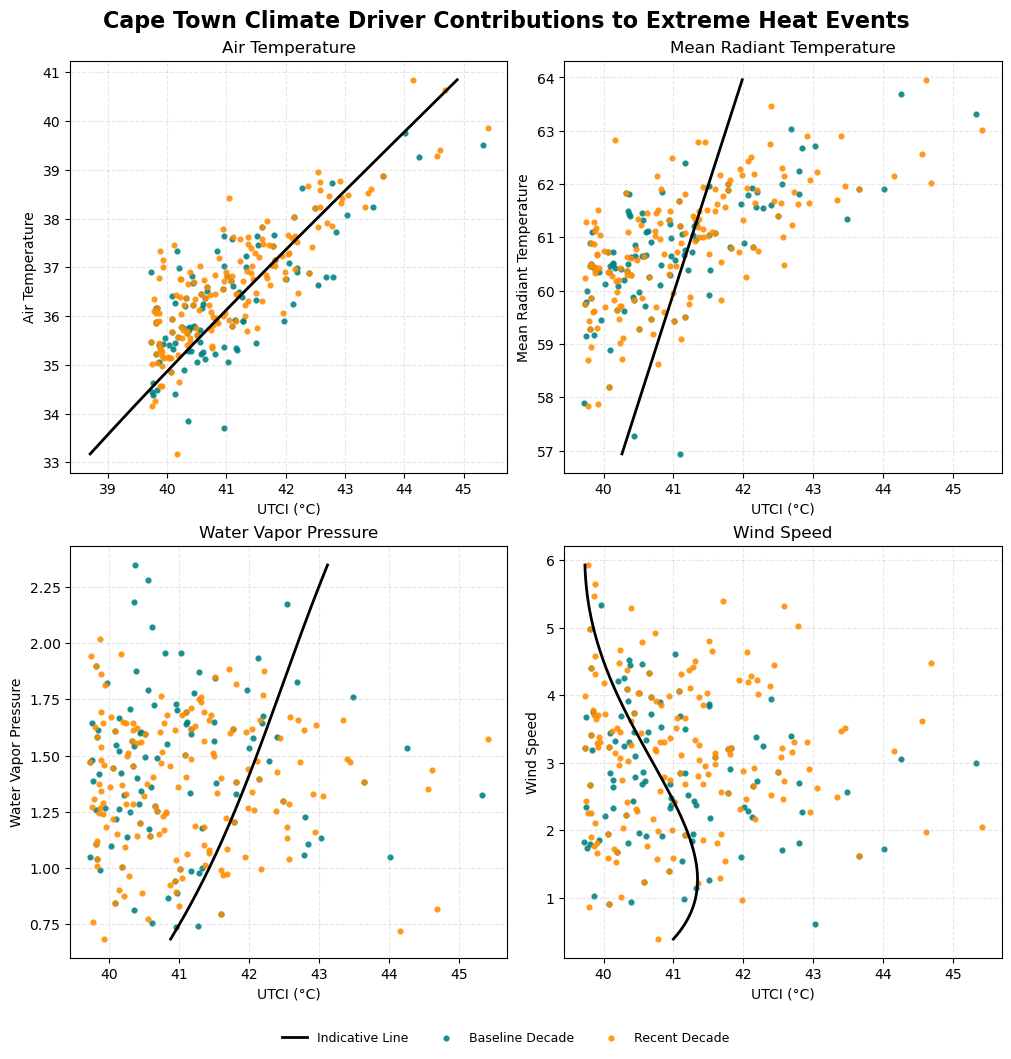

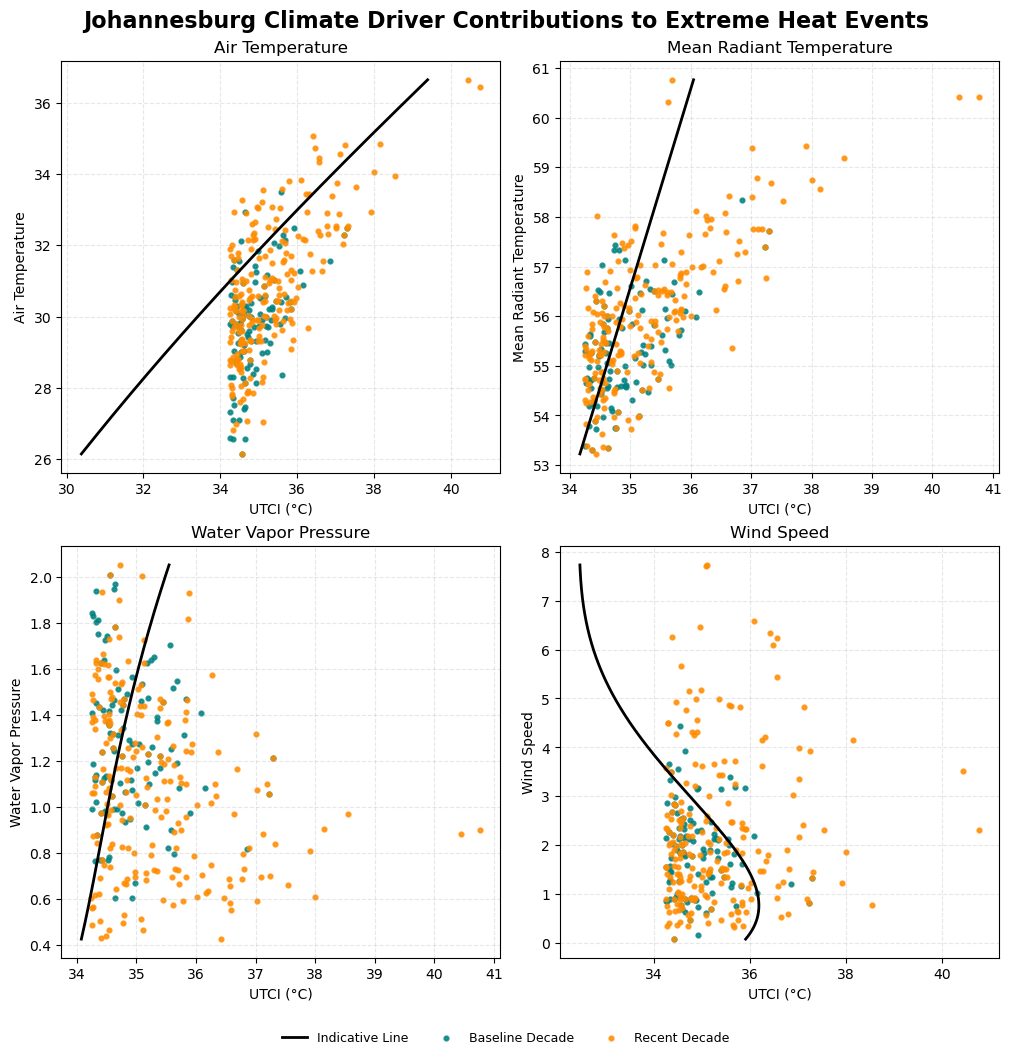

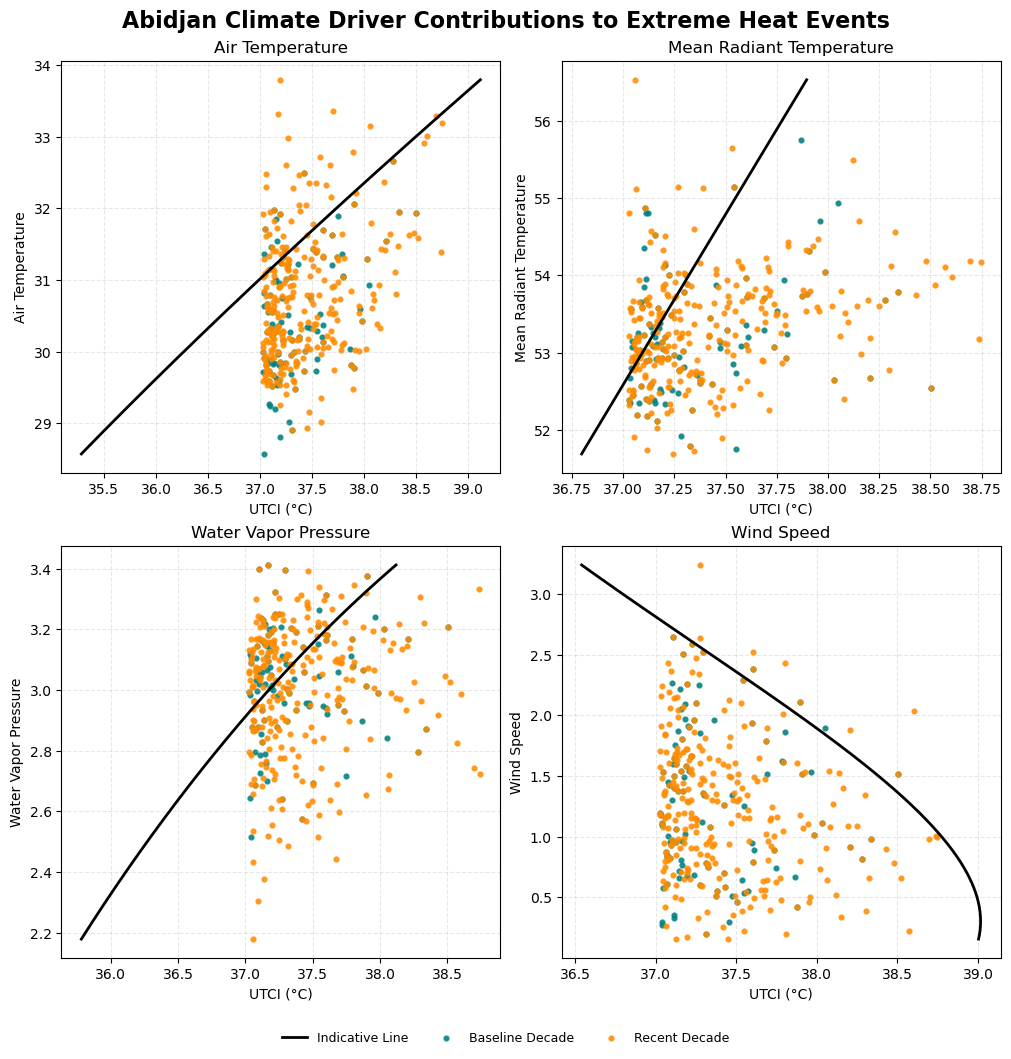

In [4]:
# Location coordinates
locations = {
    'cpt': (-33.6, 18.6),
    'jhb': (-26.1, 28.0),
    'abj': (5.45, -3.9)
}

names = {'cpt': 'Cape Town', 'jhb': 'Johannesburg', 'abj': 'Abidjan'}


for name in list(names):
    lat, lon = locations[name]
    variables = [ 'UTCI', 'tas', 'MRT', 'wvp', 'ws']
    path = '../create_analysis_dataset/data/'
    path = 'data/'
    heat_index = 'UTCI'  
    baseline_period = slice('1970', '1999')
    recent_period = slice('1993', '2022')

    ds = xr.open_zarr(f'{path}/heat_analysis_set.zarr')
    ds = ds.sel(latitude = slice(20,-60))
    ds['rh'] = calculate_relative_humidity_percent(ds.tas, ds.tasdp)
    ds['wvp'] = (calculate_saturation_vapour_pressure(ds.tas) * ds.rh / 100.0) / 10.0  # water vapour pressure in kPa

    ds = ds[variables]

    ds = ds.chunk({'time': 1000, 'latitude':30, 'longitude':30})
    ds = ds.sel(latitude=lat, longitude=lon, method='nearest')
    ds['UTCI'] = ds['UTCI'] - 273.15
    ds['tas'] = ds['tas'] - 273.15
    ds['MRT'] = ds['MRT'] - 273.15
    ds = ds.load()
    # Compute UTCI threshold using baseline period only
    UTCI_baseline = ds['UTCI'].sel(time=baseline_period)
    UTCI_threshold = UTCI_baseline.quantile(0.99, skipna=True).compute()
    ds = ds.where(ds.UTCI > UTCI_threshold)
    ds = ds.dropna(how = 'all', dim = 'time')
    mins = ds.min()
    maxs = ds.max()
    if name == 'cpt':
        #idx_closest_to_median = np.abs(ds.UTCI - ds.UTCI.max()).argmin()
        idx_closest_to_median = np.abs(ds.UTCI - ds.UTCI.median()).argmin()
    else:
        idx_closest_to_median = np.abs(ds.UTCI - ds.UTCI.median()).argmin()
    means = ds.isel(time = idx_closest_to_median) # maxs #(maxs + mins) / 2 # mins + (maxs - mins) #ds.median()
    titles = {
        'tas': 'Air Temperature',
        'MRT': 'Mean Radiant Temperature',
        'wvp': 'Water Vapor Pressure',
        'ws': 'Wind Speed'
    }

    variables = ['tas', 'MRT', 'wvp', 'ws']
    import matplotlib.pyplot as plt

    vars_to_plot = ['tas', 'MRT', 'wvp', 'ws']
    colors = plt.get_cmap('tab10').colors

    # Colors for baseline and recent decades
    baseline_color = 'teal' 
    recent_color = 'darkorange' 

    # Create figure and axes
    fig, axes = plt.subplots(
        nrows=2, ncols=2,
        figsize=(10, 10),
        constrained_layout=True
    )
    axes = axes.flatten()

    for i, (ax, var) in enumerate(zip(axes, vars_to_plot)):
        var_range = np.linspace(mins[var].item(), maxs[var].item(), 1000)
        UTCI_range = compute_indicative_UTCIS(means, var, var_range)

        # Plot the indicative line
        ax.plot(UTCI_range, var_range, color='black', linewidth=2, label='Indicative Line')

        # Scatter plots for baseline and recent periods
        baseline_scatter = ax.scatter(
            ds.sel(time=baseline_period).UTCI,
            ds.sel(time=baseline_period)[var],
            color=baseline_color,
            alpha=0.8,
            linewidth=1.5,
            marker='.',
            label='Baseline Decade'
        )
        recent_scatter = ax.scatter(
            ds.sel(time=recent_period).UTCI,
            ds.sel(time=recent_period)[var],
            color=recent_color,
            alpha=0.8,
            linewidth=1.5,
            marker='.',
            label='Recent Decade'
        )

        ax.set_title(f"{titles.get(var, var)}", fontsize=12)
        ax.set_xlabel("UTCI (°C)", fontsize=10)
        ax.set_ylabel(f"{titles.get(var, var)}", fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.3)

    # Add a shared legend below the plots
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles[:3], labels[:3], loc='lower center', ncol=3, fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.05))

    fig.suptitle(f"{names[name]} Climate Driver Contributions to Extreme Heat Events", fontsize=16, fontweight='bold')

    plt.savefig(f'plots/04_driver_vs_utci_scatter_{name}.png', dpi=300, bbox_inches='tight')
    plt.show()


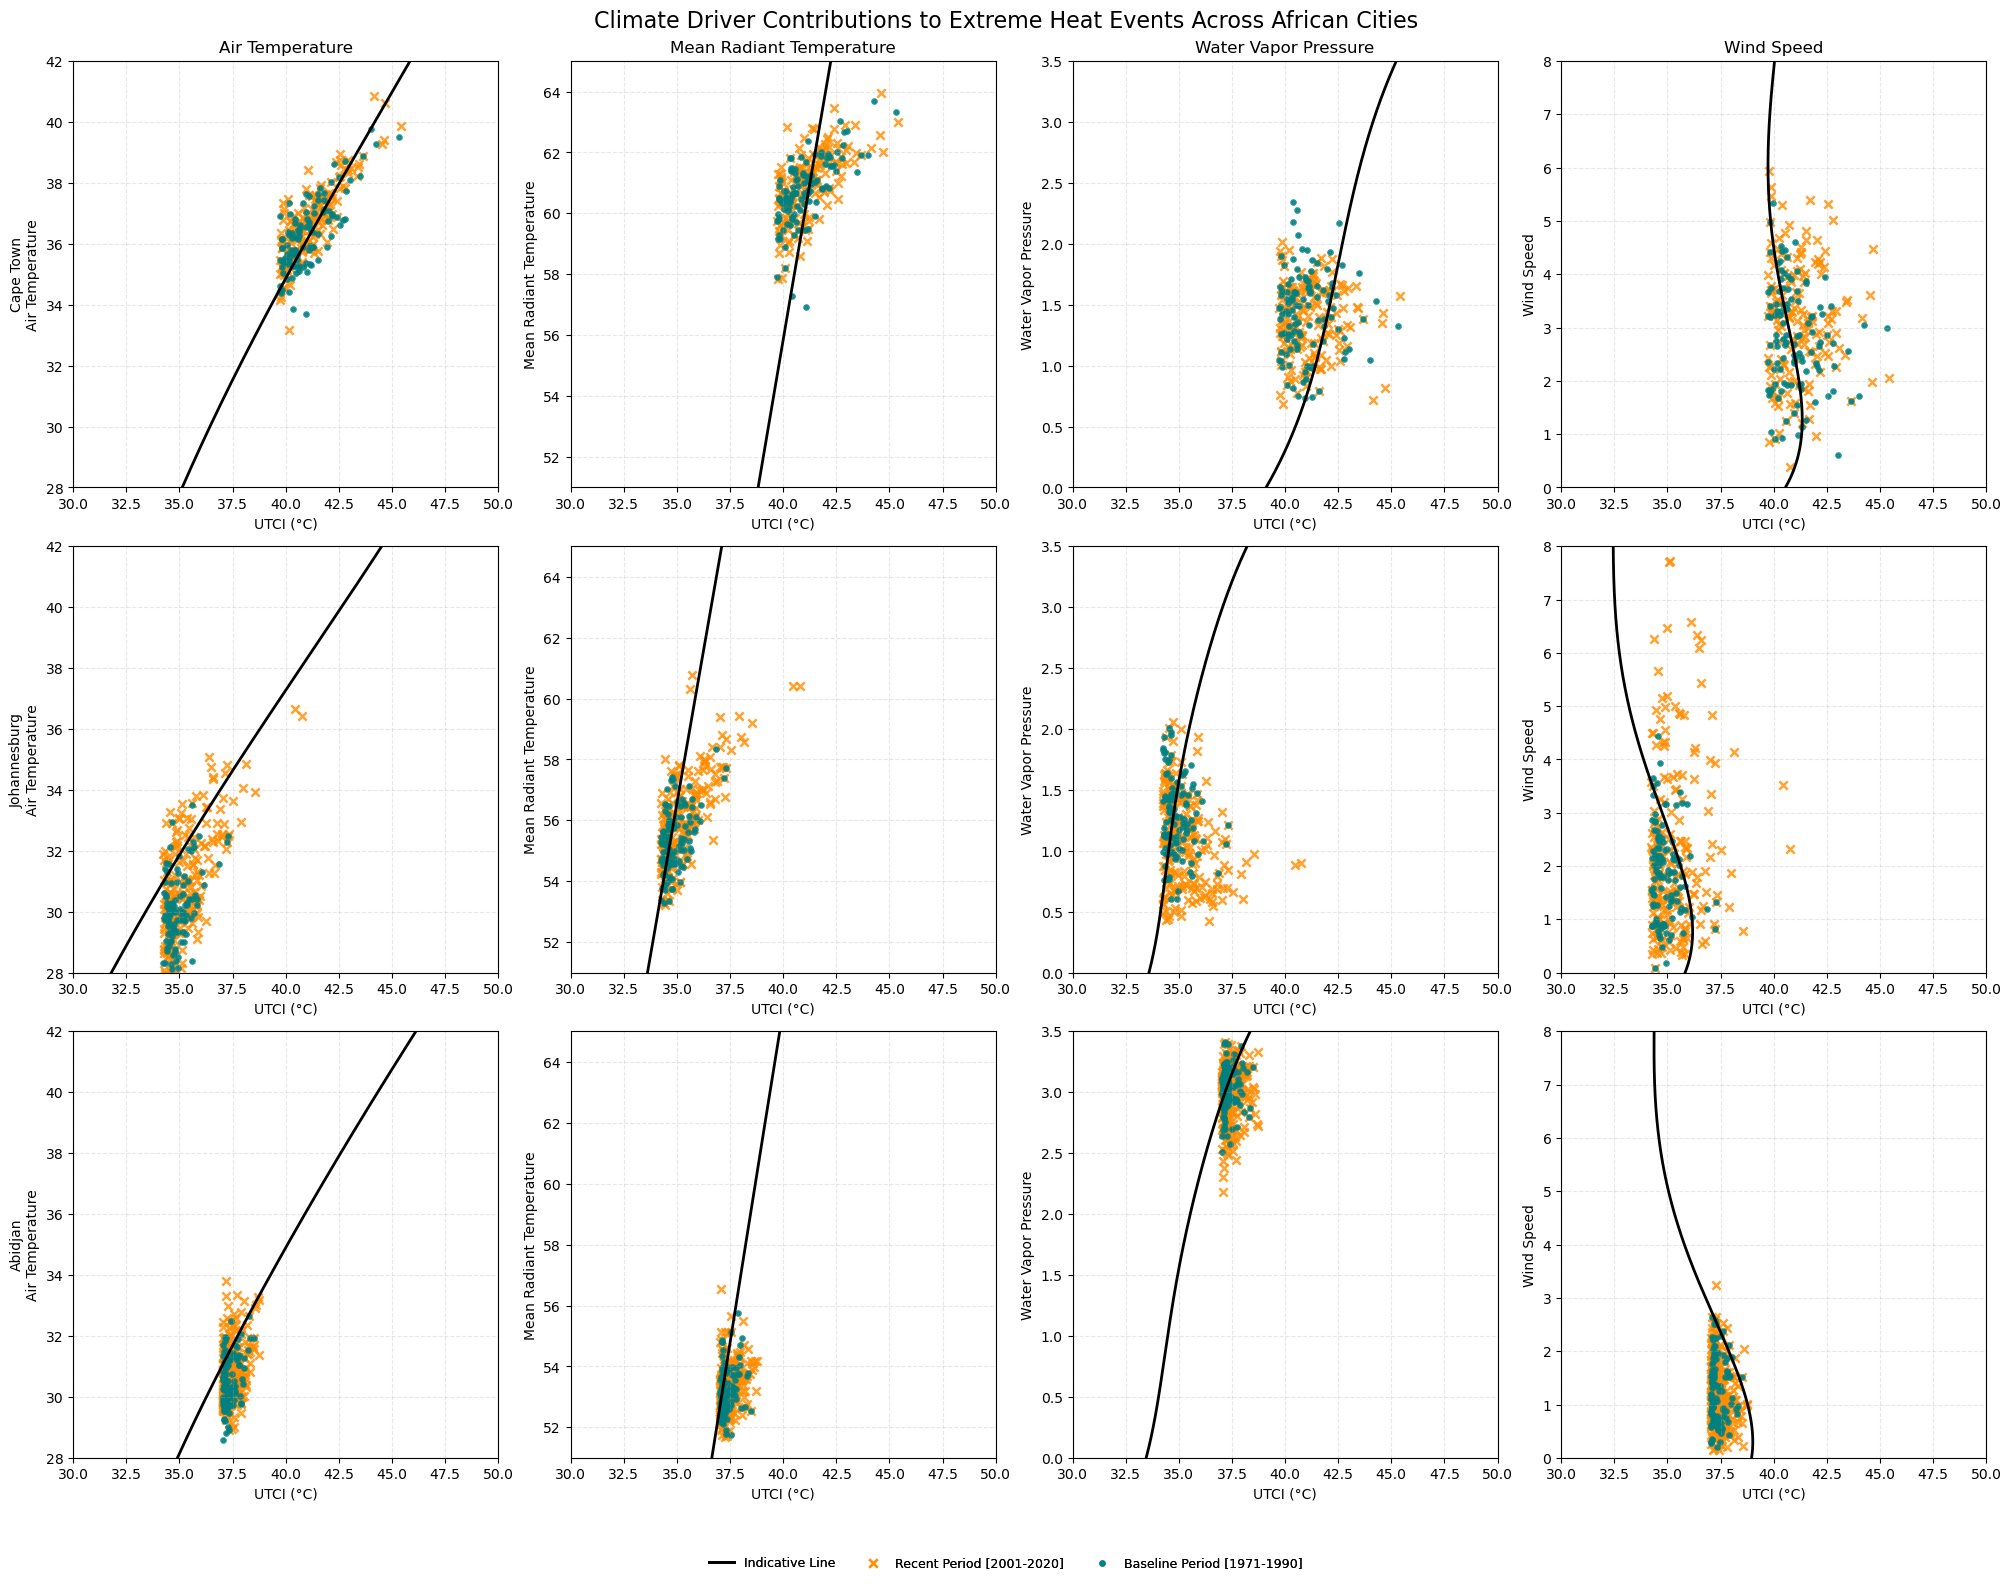

In [5]:
x_range = [30, 50]  # UTCI range
y_ranges = {
    'tas': [28, 42],    # Air temperature range
    'MRT': [51, 65],    # Mean radiant temperature range
    'wvp': [0, 3.5],      # Water vapor pressure range
    'ws': [0, 8]       # Wind speed range
}

# Create a single figure with cities as rows and drivers as columns
fig, axes = plt.subplots(
    nrows=3, ncols=4,  # 3 cities, 4 drivers
    figsize=(20, 15),
    constrained_layout=True
)

# Colors for baseline and recent decades
baseline_color = 'teal' 
recent_color = 'darkorange' 

# Loop through cities
for row, (city_name, (lat, lon)) in enumerate(locations.items()):
    # Load and process data for this city
    ds = xr.open_zarr(f'{path}/heat_analysis_set.zarr')
    ds = ds.sel(latitude = slice(20,-60))
    ds['rh'] = calculate_relative_humidity_percent(ds.tas, ds.tasdp)
    ds['wvp'] = (calculate_saturation_vapour_pressure(ds.tas) * ds.rh / 100.0) / 10.0
    variables = ['UTCI','tas', 'MRT', 'wvp', 'ws']
    ds = ds[variables]
    ds = ds.chunk({'time': 1000, 'latitude':30, 'longitude':30})
    ds = ds.sel(latitude=lat, longitude=lon, method='nearest')
    ds['UTCI'] = ds['UTCI'] - 273.15
    ds['tas'] = ds['tas'] - 273.15
    ds['MRT'] = ds['MRT'] - 273.15
    ds = ds.load()
    
    # Compute UTCI threshold using baseline period only
    UTCI_baseline = ds['UTCI'].sel(time=baseline_period)
    UTCI_threshold = UTCI_baseline.quantile(0.99, skipna=True).compute()
    ds = ds.where(ds.UTCI > UTCI_threshold)
    ds = ds.dropna(how = 'all', dim = 'time')
    
    mins = ds.min()
    maxs = ds.max()
    idx_closest_to_median = np.abs(ds.UTCI - ds.UTCI.median()).argmin()
    means = ds.isel(time = idx_closest_to_median)
    vars_to_plot = ['tas', 'MRT', 'wvp', 'ws']
    # Plot each driver for this city
    for col, var in enumerate(vars_to_plot):
        ax = axes[row, col]
        ax.set_xlim(x_range)
        ax.set_ylim(y_ranges[var])
        
        #var_range = np.linspace(mins[var].item(), maxs[var].item(), 1000)
        var_range = np.linspace(y_ranges[var][0], y_ranges[var][1], 1000)
        UTCI_range = compute_indicative_UTCIS(means, var, var_range)

        # Plot the indicative line
        ax.plot(UTCI_range, var_range, color='black', linewidth=2, label='Indicative Line')

        # Scatter plots for baseline and recent periods
        recent_scatter = ax.scatter(
            ds.sel(time=recent_period).UTCI,
            ds.sel(time=recent_period)[var],
            color=recent_color,
            alpha=0.8,
            linewidth=1.8,
            marker='x',
            label='Recent Period [2001-2020]'
        )

        baseline_scatter = ax.scatter(
            ds.sel(time=baseline_period).UTCI,
            ds.sel(time=baseline_period)[var],
            color=baseline_color,
            alpha=0.8,
            linewidth=1.8,
            marker='.',
            label='Baseline Period [1971-1990]'
        )

        # Set labels and title
        if row == 0:  # Only add titles to top row
            ax.set_title(f"{titles.get(var, var)}", fontsize=12)
        if col == 0:  # Only add city names to first column
            ax.set_ylabel(f"{names[city_name]}\n{titles.get(var, var)}", fontsize=10)
        else:
            ax.set_ylabel(f"{titles.get(var, var)}", fontsize=10)
        ax.set_xlabel("UTCI (°C)", fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.3)

# Add a shared legend below the plots
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles[:3], labels[:3], loc='lower center', ncol=3, fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.05))

fig.suptitle("Climate Driver Contributions to Extreme Heat Events Across African Cities", fontsize=16)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles[:3], labels[:3], 
          loc='lower center', 
          ncol=3, 
          fontsize=9, 
          frameon=False,
          bbox_to_anchor=(0.5, -0.05))

plt.savefig('plots/04_driver_vs_utci_scatter_combined.png', dpi=300, bbox_inches='tight')
plt.show()